SEQUENTIAL MODEL WITH ZIGZAG_TRACE DATASET

In [177]:
import pandas as pd

In [179]:
# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_trace.csv")

In [183]:
# Display basic information about the dataset
print(data.head())

   Class    Width   Height        Length  Velocity    P_max_V   P_min_V  \
0      0  1740.85  1746.72  10392.630070  0.357846  64.031242  0.052910   
1      0  1563.31  1568.23  13551.886580  0.465277  55.477723  0.050251   
2      0  1466.88  1473.87  13733.025370  0.469485  76.157731  0.044743   
3      0  1688.38  1695.41   8389.808236  0.289389  44.721360  0.045455   
4      0  1858.82  1863.86   8965.734841  0.310543  61.463630  0.029481   

      P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0  640.312424  0.002799  638.060000  ...      0   17159.57143              0   
1  447.213595  0.002525  609.225000  ...      0   17975.16667              0   
2  761.577311  0.002002  594.533333  ...      0   22173.80952              0   
3  447.213595  0.002066  657.870000  ...      0   21037.68750              0   
4  447.213595  0.000869  683.480000  ...      0   20124.11765              0   

   AngleMean     AngleVar  ReglineSlope  ReglineIntercept    LoopCou

In [191]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Class             87 non-null     int64  
 1   Width             87 non-null     float64
 2   Height            87 non-null     float64
 3   Length            87 non-null     float64
 4   Velocity          87 non-null     float64
 5   P_max_V           87 non-null     float64
 6   P_min_V           87 non-null     float64
 7   P_max_A           87 non-null     float64
 8   P_min_A           87 non-null     float64
 9   GA_mean_H         87 non-null     float64
 10  GA_mean_V         87 non-null     float64
 11  GA_SD_H           87 non-null     float64
 12  GA_SD_V           87 non-null     float64
 13  PressureMean      87 non-null     float64
 14  PressureSD        87 non-null     float64
 15  PCAvgPos          87 non-null     float64
 16  PCSDPos           87 non-null     float64
 17 

In [193]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and labels
X = data.iloc[:, 1:]  # Features (excluding 'Class')
y = data.iloc[:, 0]   # Labels ('Class')

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


In [195]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

# Build a neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification (output: 0 or 1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=20, validation_data=(X_test, y_test))


Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4115 - loss: 2.0785 - val_accuracy: 0.3889 - val_loss: 2.0252
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3783 - loss: 1.9942 - val_accuracy: 0.3333 - val_loss: 1.9825
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6027 - loss: 1.9713 - val_accuracy: 0.2778 - val_loss: 1.9545
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4687 - loss: 1.9168 - val_accuracy: 0.2778 - val_loss: 1.9221
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5711 - loss: 1.8630 - val_accuracy: 0.3333 - val_loss: 1.8962
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6085 - loss: 1.7872 - val_accuracy: 0.3333 - val_loss: 1.8675
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6450 - loss: 1.8021 - val_accuracy: 0.4444 - val_loss: 1.8267
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5137 - loss: 1.7420 - val_accuracy: 0.3333 - val_loss: 1.7872
Epoch 9/100

1/1 [==============================] - 0s 27ms/step - loss: 0.7671 - accuracy: 0.7778
Test Accuracy: 0.78


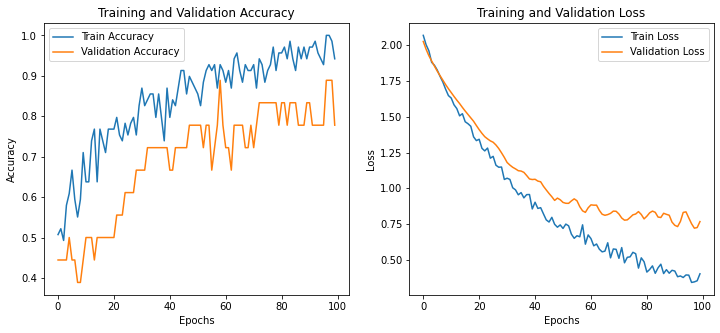

In [4]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot training history (accuracy and loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


LSTM(LONG SHORT TERM MEMORY) & CNN(CONVOLUTIONAL NEURAL NETWORK) METHOD WITH ZIGZAG_TRACE DATASET

In [187]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [189]:
# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_trace.csv")

# Separate features and labels
X = data.iloc[:, 1:].values  # Features (excluding 'Class')
y = data.iloc[:, 0].values   # Labels ('Class')

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Reshape features for CNN-LSTM input (samples, time_steps, features)
X_reshaped = X_normalized.reshape(X_normalized.shape[0], X_normalized.shape[1], 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras import regularizers

# # Load the data
# data = pd.read_csv('data/data.csv')

# # Split the data into train and test sets
# X_train, X_test, y_train, y_test = train_test_

# Build a CNN-LSTM model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(1, activation='sigmoid')  # Binary classification (output: 0 or 1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=25, validation_data=(X_test, y_test))


Epoch 1/100
3/3 [==============================] - 5s 474ms/step - loss: 1.5614 - accuracy: 0.4928 - val_loss: 1.5323 - val_accuracy: 0.6111
Epoch 2/100
3/3 [==============================] - 0s 33ms/step - loss: 1.5287 - accuracy: 0.4783 - val_loss: 1.5032 - val_accuracy: 0.7222
Epoch 3/100
3/3 [==============================] - 0s 27ms/step - loss: 1.4993 - accuracy: 0.5362 - val_loss: 1.4752 - val_accuracy: 0.8333
Epoch 4/100
3/3 [==============================] - 0s 27ms/step - loss: 1.4725 - accuracy: 0.4348 - val_loss: 1.4493 - val_accuracy: 0.5556
Epoch 5/100
3/3 [==============================] - 0s 30ms/step - loss: 1.4409 - accuracy: 0.5797 - val_loss: 1.4229 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 31ms/step - loss: 1.4135 - accuracy: 0.6087 - val_loss: 1.3977 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 28ms/step - loss: 1.3891 - accuracy: 0.5652 - val_loss: 1.3736 - val_accuracy: 0.5000
Epoch 8/100
3/3 [==

1/1 [==============================] - 0s 28ms/step - loss: 0.8189 - accuracy: 0.6111
Test Accuracy: 0.61


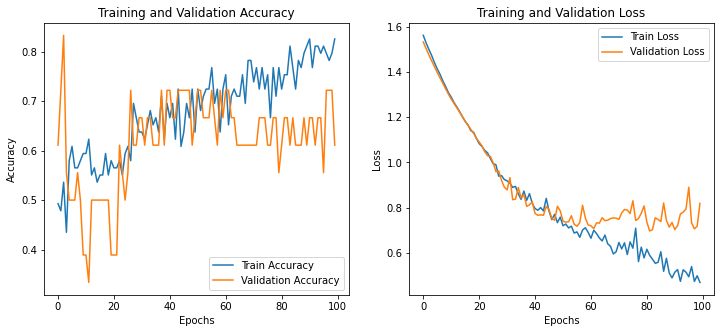

In [7]:
import matplotlib.pyplot as plt

# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


CNN-LSTM BASED MODEL WITH ZIGZAG_TRACE DATASET (DATA PREPROCESSED BY SFFS METHOD)

In [197]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_trace.csv")

# Display basic information
print(data.head())
print(f"Dataset shape: {data.shape}")


   Class    Width   Height        Length  Velocity    P_max_V   P_min_V  \
0      0  1740.85  1746.72  10392.630070  0.357846  64.031242  0.052910   
1      0  1563.31  1568.23  13551.886580  0.465277  55.477723  0.050251   
2      0  1466.88  1473.87  13733.025370  0.469485  76.157731  0.044743   
3      0  1688.38  1695.41   8389.808236  0.289389  44.721360  0.045455   
4      0  1858.82  1863.86   8965.734841  0.310543  61.463630  0.029481   

      P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0  640.312424  0.002799  638.060000  ...      0   17159.57143              0   
1  447.213595  0.002525  609.225000  ...      0   17975.16667              0   
2  761.577311  0.002002  594.533333  ...      0   22173.80952              0   
3  447.213595  0.002066  657.870000  ...      0   21037.68750              0   
4  447.213595  0.000869  683.480000  ...      0   20124.11765              0   

   AngleMean     AngleVar  ReglineSlope  ReglineIntercept    LoopCou

In [199]:
# Separate features and labels
X = data.iloc[:, 1:].values  # Features (excluding 'Class')
y = data.iloc[:, 0].values   # Labels ('Class')

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)


In [201]:
# Initialize a classifier for feature selection
clf = RandomForestClassifier(random_state=42)

# Apply SFFS
sffs = SFS(clf,
           k_features=10    ,  # Select top 10 features
           forward=True,
           floating=True,  # Enable floating (SFFS)
           scoring='accuracy',
           cv=5)

sffs = sffs.fit(X_normalized, y)

# Get selected feature indices
selected_features = list(sffs.k_feature_idx_)
print("Selected Features:", selected_features)
print("Feature names:", [data.columns[i+1] for i in selected_features])

# Reduce dataset to selected features
X_selected = X_normalized[:, selected_features]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


Selected Features: [3, 5, 6, 16, 17, 19, 20, 25, 28, 29]
Feature names: ['Velocity', 'P_min_V', 'P_max_A', 'PCMax', 'PCAvgNeg', 'PCMin', 'Error', 'ReglineSlope', 'AngleSpeed', 'ErrorRate']


In [203]:
# Reshape data for deep learning input (samples, time_steps, features)
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build hybrid CNN-LSTM model
model = tf.keras.Sequential([
    # CNN layers for feature extraction
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Dropout(0.3),
    
    # LSTM layers for sequential pattern learning
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.LSTM(32),
    
    # Dense layers for classification
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Use early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_reshaped, 
    y_train, 
    epochs=100, 
    batch_size=20, 
    validation_split=0.2,
    callbacks=[early_stopping]
)

# Save the trained model
model.save("handwriting_classifier_model.h5")


Epoch 1/100
3/3 [==============================] - 7s 605ms/step - loss: 0.6930 - accuracy: 0.5273 - val_loss: 0.6922 - val_accuracy: 0.7143
Epoch 2/100
3/3 [==============================] - 0s 27ms/step - loss: 0.6923 - accuracy: 0.6000 - val_loss: 0.6921 - val_accuracy: 0.5714
Epoch 3/100
3/3 [==============================] - 0s 28ms/step - loss: 0.6917 - accuracy: 0.5091 - val_loss: 0.6916 - val_accuracy: 0.5714
Epoch 4/100
3/3 [==============================] - 0s 51ms/step - loss: 0.6917 - accuracy: 0.5818 - val_loss: 0.6918 - val_accuracy: 0.5714
Epoch 5/100
3/3 [==============================] - 0s 30ms/step - loss: 0.6918 - accuracy: 0.5455 - val_loss: 0.6914 - val_accuracy: 0.5714
Epoch 6/100
3/3 [==============================] - 0s 30ms/step - loss: 0.6925 - accuracy: 0.5091 - val_loss: 0.6906 - val_accuracy: 0.5714
Epoch 7/100
3/3 [==============================] - 0s 30ms/step - loss: 0.6887 - accuracy: 0.5273 - val_loss: 0.6892 - val_accuracy: 0.7143
Epoch 8/100
3/3 [==

1/1 [==============================] - 0s 44ms/step - loss: 0.6567 - accuracy: 0.6111
Test Accuracy: 0.6111
1/1 [==============================] - 1s 1s/step
              precision    recall  f1-score   support

           0       0.54      0.88      0.67         8
           1       0.80      0.40      0.53        10

    accuracy                           0.61        18
   macro avg       0.67      0.64      0.60        18
weighted avg       0.68      0.61      0.59        18



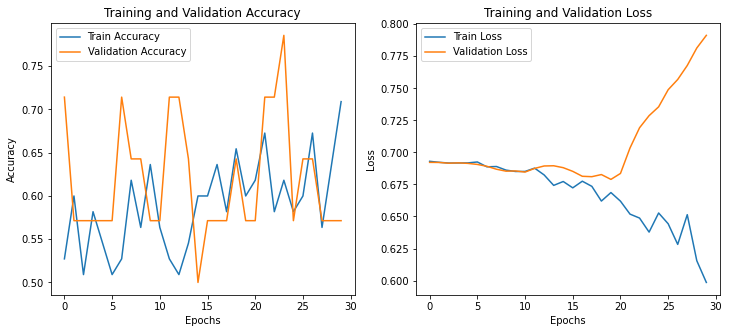

In [7]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred_prob = model.predict(X_test_reshaped)
y_pred = (y_pred_prob > 0.5).astype(int)

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


In [205]:
import pandas as pd

# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_predict.csv")

# Display basic information about the dataset
print(data.head())
print(data.info())


   Class    Width   Height        Length  Velocity     P_max_V   P_min_V  \
0      0  1260.00  1264.26  10408.522420  0.364835   72.801099  0.045126   
1      0  1847.33  1864.61  14828.091520  0.535509   82.462113  0.023414   
2      0  2172.94  2178.29  19891.906100  0.694213  110.000000  0.052083   
3      0  2082.54  2088.37   9101.507747  0.329171   58.309519  0.038314   
4      0  2386.85  2393.03  13376.351360  0.487068  114.017543  0.030395   

       P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0   728.010989  0.002036  578.085000  ...      0   17361.30000              0   
1   824.621125  0.000548  680.588333  ...      0   20025.17857              0   
2  1100.000000  0.002455  712.521667  ...      0   20408.12500              0   
3   583.095189  0.001468  721.950000  ...      0   19485.94737              0   
4  1140.175425  0.000924  762.843333  ...      0   20029.10000              0   

   AngleMean    AngleVar  ReglineSlope  ReglineIntercept

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and labels
X = data.iloc[:, 1:]  # Features (excluding 'Class')
y = data.iloc[:, 0]   # Labels ('Class')

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


In [207]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

# Build a neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification (output: 0 or 1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=20, validation_data=(X_test, y_test))


Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5919 - loss: 1.7152 - val_accuracy: 0.5556 - val_loss: 1.6850
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5228 - loss: 1.6561 - val_accuracy: 0.5000 - val_loss: 1.6454
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5636 - loss: 1.6094 - val_accuracy: 0.4444 - val_loss: 1.6027
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6118 - loss: 1.5820 - val_accuracy: 0.4444 - val_loss: 1.5645
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5701 - loss: 1.5663 - val_accuracy: 0.5000 - val_loss: 1.5264
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6534 - loss: 1.5040 - val_accuracy: 0.5000 - val_loss: 1.4923
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6267 - loss: 1.4595 - val_accuracy: 0.5556 - val_loss: 1.4599
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6568 - loss: 1.4054 - val_accuracy: 0.4444 - val_loss: 1.4293
Epoch 9/100

1/1 [==============================] - 0s 31ms/step - loss: 2.5025 - accuracy: 0.5556
Test Accuracy: 0.56


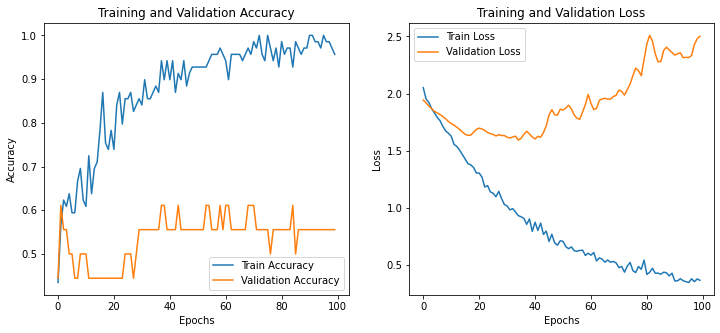

In [5]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot training history (accuracy and loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


In [209]:
import pandas as pd

# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Pl_trace.csv")

# Display basic information about the dataset
print(data.head())
print(data.info())


   Class    Width   Height       Length  Velocity     P_max_V   P_min_V  \
0      0  1517.92  1524.69  9751.285947  0.333429   42.426407  0.045872   
1      0  1967.66  1972.90  9010.322162  0.312660  140.000000  0.041595   
2      0  1735.28  1742.39  9269.643116  0.319433   57.008771  0.048780   
3      0  1716.38  1723.29  4705.010585  0.162146   28.284271  0.029922   
4      0  1855.51  1860.16  5006.821946  0.173050   31.622777  0.036563   

       P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0   424.264069  0.002104  588.026667  ...      1   16646.77778     389.300000   
1  1400.000000  0.001223  670.003333  ...      3   20705.17647     370.313333   
2   500.000000  0.002380  639.085000  ...      2   19065.50000     444.540000   
3   282.842713  0.000253  639.628333  ...      0   18401.27273       0.000000   
4   316.227766  0.001337  690.866667  ...      2   17502.25000     549.050000   

   AngleMean    AngleVar  ReglineSlope  ReglineIntercept    Lo

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and labels
X = data.iloc[:, 1:]  # Features (excluding 'Class')
y = data.iloc[:, 0]   # Labels ('Class')

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

In [211]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

# Build a neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification (output: 0 or 1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=20, validation_data=(X_test, y_test))


Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4979 - loss: 1.7086 - val_accuracy: 0.3333 - val_loss: 1.6879
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5071 - loss: 1.6637 - val_accuracy: 0.3889 - val_loss: 1.6448
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5861 - loss: 1.5895 - val_accuracy: 0.3889 - val_loss: 1.6043
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5378 - loss: 1.5961 - val_accuracy: 0.5000 - val_loss: 1.5671
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5370 - loss: 1.5228 - val_accuracy: 0.5000 - val_loss: 1.5297
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5951 - loss: 1.4870 - val_accuracy: 0.5556 - val_loss: 1.4938
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5054 - loss: 1.4864 - val_accuracy: 0.5000 - val_loss: 1.4583
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5651 - loss: 1.4327 - val_accuracy: 0.5556 - val_loss: 1.4259
Epoch 9/100

1/1 [==============================] - 0s 30ms/step - loss: 2.1276 - accuracy: 0.7222
Test Accuracy: 0.72


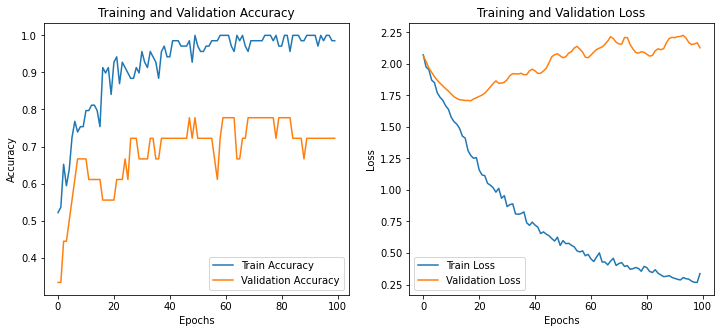

In [4]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot training history (accuracy and loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Pl_predict.csv")

# Display basic information about the dataset
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

# Check class distribution
print("\nClass distribution:")
print(data['Class'].value_counts())


Dataset shape: (87, 31)

First few rows:
   Class    Width   Height        Length  Velocity     P_max_V   P_min_V  \
0      0  1678.33  1690.52  10554.738760  0.376449   63.245553  0.043478   
1      0  1404.52  1410.52  12300.170310  0.433895  114.017543  0.026316   
2      0  1491.17  1496.69  12322.608700  0.419819   72.801099  0.044843   
3      0  2062.65  2069.22   3875.415536  0.140498   30.000000  0.014514   
4      0  2195.18  2201.24   3713.283211  0.135061   50.000000  0.018904   

       P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0   632.455532  0.001890  628.278333  ...      1   22072.83333     337.700000   
1  1140.175425  0.000693  602.680000  ...      1   19213.85000     287.200000   
2   728.010989  0.001409  591.216667  ...      3   15498.68182     175.493333   
3   282.842713  0.000211  694.453333  ...      2   17186.37500    1112.250000   
4   316.227766  0.000357  743.930000  ...      0   18838.33333       0.000000   

   AngleMean   

In [215]:
# Separate features and target
X = data.iloc[:, 1:]  # All columns except 'Class'
y = data.iloc[:, 0]   # 'Class' column

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame for better readability
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)
print("\nNormalized features:")
print(X_normalized_df.head())



Normalized features:
      Width    Height    Length  Velocity   P_max_V   P_min_V   P_max_A  \
0 -0.584149 -0.572126  1.105718  1.097223  0.686573  1.033506  0.839755   
1 -0.742340 -0.730653  1.629408  1.585181  2.362830 -0.512839  2.391498   
2 -0.692279 -0.681866  1.636140  1.465622  1.002053  1.156474  1.131801   
3 -0.362112 -0.357719 -0.898312 -0.907025 -0.411042 -1.576204 -0.228766   
4 -0.285544 -0.282974 -0.946957 -0.953209  0.249265 -1.180681 -0.126731   

    P_min_A  GA_mean_H  GA_mean_V  ...     Error  PeakpresMean  ErrorStopTime  \
0  1.301296  -0.494283  -0.491718  ... -0.205586      0.201922      -0.040919   
1 -0.425250  -0.563573  -0.561557  ... -0.205586     -0.445889      -0.204430   
2  0.607031  -0.594602  -0.586236  ...  1.497842     -1.287700      -0.566119   
3 -1.119811  -0.315158  -0.316308  ...  0.646128     -0.905290       2.466957   
4 -0.908366  -0.181234  -0.183076  ... -1.057300     -0.530976      -1.134340   

   AngleMean  AngleVar  ReglineSlope  Re

In [217]:
# Initialize MLP classifier for feature selection
base_mlp = MLPClassifier(max_iter=1000, random_state=42)

# Apply Sequential Forward Floating Selection (SFFS)
sffs = SFS(
    base_mlp, 
    k_features=15,  # Select top 15 features (can be adjusted)
    forward=True, 
    floating=True,  # Enable "floating" for SFFS
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit SFFS
print("\nPerforming SFFS feature selection (this may take a while)...")
sffs = sffs.fit(X_normalized, y)

# Get selected feature indices and names
selected_features_idx = list(sffs.k_feature_idx_)
selected_features = [X.columns[i] for i in selected_features_idx]

print(f"\nSelected {len(selected_features)} features:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

# Create dataset with selected features
X_selected = X_normalized[:, selected_features_idx]



Performing SFFS feature selection (this may take a while)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo


Selected 15 features:
1. P_max_V
2. P_min_V
3. P_max_A
4. P_min_A
5. GA_mean_H
6. PCAvgPos
7. PCSDPos
8. PCMax
9. PCAvgNeg
10. PCSDNeg
11. PCMin
12. AngleMean
13. AngleVar
14. ReglineSlope
15. LoopCount


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [1000]
}

# Create MLP classifier
mlp = MLPClassifier(random_state=42)

# Perform grid search with cross-validation
print("\nPerforming hyperparameter tuning...")
grid_search = GridSearchCV(
    mlp, param_grid, scoring='accuracy', cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Get best hyperparameters
best_params = grid_search.best_params_
print("\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

# Train final model with best hyperparameters
best_mlp = MLPClassifier(**best_params, random_state=42)
best_mlp.fit(X_train, y_train)

# Save the model for later use
import joblib
joblib.dump(best_mlp, "handwriting_mlp_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(selected_features_idx, "selected_features.pkl")



Performing hyperparameter tuning...

Best hyperparameters:
activation: relu
alpha: 0.001
hidden_layer_sizes: (64, 32)
learning_rate: constant
max_iter: 1000


['selected_features.pkl']


Test Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.89      0.89      0.89         9

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18



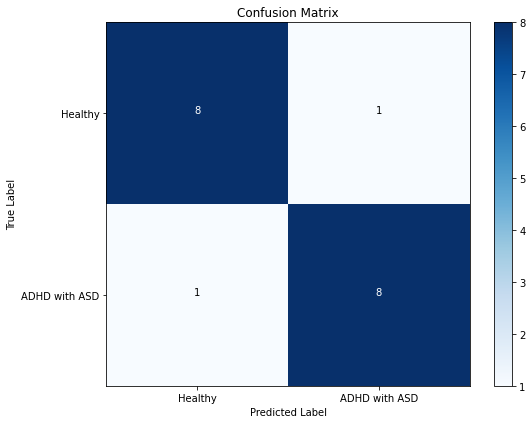

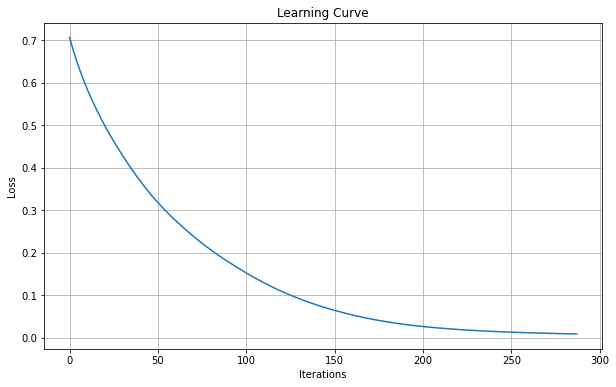

In [6]:
# Evaluate model on test set
y_pred = best_mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Healthy', 'ADHD with ASD'])
plt.yticks(tick_marks, ['Healthy', 'ADHD with ASD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(best_mlp.loss_curve_)
plt.title('Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()



Feature Importance:
         Feature  Importance
2        P_max_A    0.078724
13  ReglineSlope    0.072789
3        P_min_A    0.070189
14     LoopCount    0.070052
4      GA_mean_H    0.068210
0        P_max_V    0.068202
1        P_min_V    0.067700
11     AngleMean    0.066467
6        PCSDPos    0.066065
7          PCMax    0.064083
10         PCMin    0.062876
12      AngleVar    0.062629
8       PCAvgNeg    0.062240
9        PCSDNeg    0.061079
5       PCAvgPos    0.058694


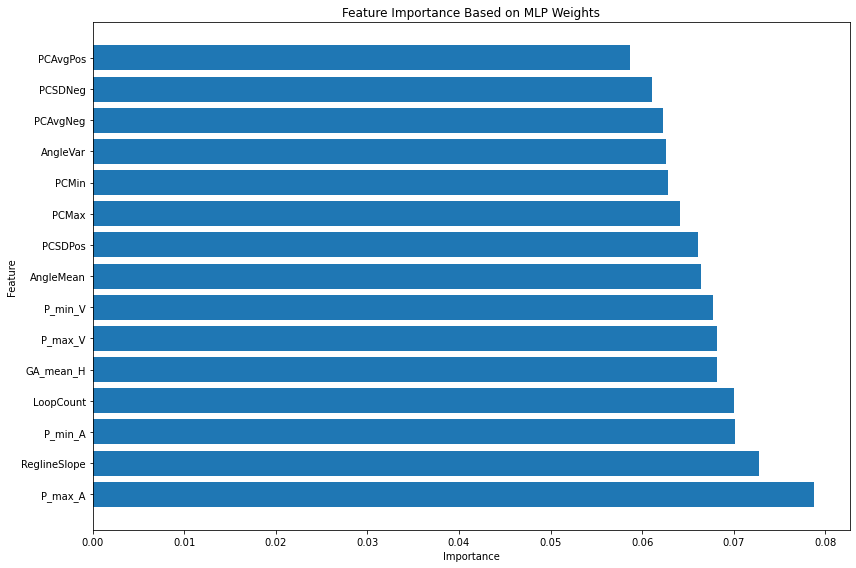

In [7]:
# Visualize feature importance using weights from the first layer
def get_feature_importance(model, feature_names):
    # Get absolute weights from the first layer
    weights = np.abs(model.coefs_[0])
    importance = np.sum(weights, axis=1)
    importance = importance / np.sum(importance)  # Normalize
    
    # Create DataFrame for better visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    return importance_df.sort_values('Importance', ascending=False)

# Get feature importance
feature_importance = get_feature_importance(best_mlp, selected_features)
print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Based on MLP Weights')
plt.tight_layout()
plt.show()


In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Load the dataset
data = pd.read_csv("ADHD-ASD-Dataset/Dataset/Pl_trace.csv")

# Display basic information about the dataset
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

# Check class distribution
print("\nClass distribution:")
print(data['Class'].value_counts())


Dataset shape: (87, 31)

First few rows:
   Class    Width   Height       Length  Velocity     P_max_V   P_min_V  \
0      0  1517.92  1524.69  9751.285947  0.333429   42.426407  0.045872   
1      0  1967.66  1972.90  9010.322162  0.312660  140.000000  0.041595   
2      0  1735.28  1742.39  9269.643116  0.319433   57.008771  0.048780   
3      0  1716.38  1723.29  4705.010585  0.162146   28.284271  0.029922   
4      0  1855.51  1860.16  5006.821946  0.173050   31.622777  0.036563   

       P_max_A   P_min_A   GA_mean_H  ...  Error  PeakpresMean  ErrorStopTime  \
0   424.264069  0.002104  588.026667  ...      1   16646.77778     389.300000   
1  1400.000000  0.001223  670.003333  ...      3   20705.17647     370.313333   
2   500.000000  0.002380  639.085000  ...      2   19065.50000     444.540000   
3   282.842713  0.000253  639.628333  ...      0   18401.27273       0.000000   
4   316.227766  0.001337  690.866667  ...      2   17502.25000     549.050000   

   AngleMean    Angle

In [221]:
# Separate features and target
X = data.iloc[:, 1:]  # All columns except 'Class'
y = data.iloc[:, 0]   # 'Class' column

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame for better readability
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)
print("\nNormalized features:")
print(X_normalized_df.head())



Normalized features:
      Width    Height    Length  Velocity   P_max_V   P_min_V   P_max_A  \
0 -0.819212 -0.792767  0.727260  0.666360  0.291161  1.084914  0.617319   
1 -0.451884 -0.441353  0.507607  0.485030  4.749487  0.735535  4.908942   
2 -0.641682 -0.622082  0.584481  0.544159  0.957457  1.322536  0.950432   
3 -0.657119 -0.637057 -0.768673 -0.829119 -0.355021 -0.217943 -0.004701   
4 -0.543483 -0.529745 -0.679203 -0.733918 -0.202478  0.324530  0.142138   

    P_min_A  GA_mean_H  GA_mean_V  ...     Error  PeakpresMean  ErrorStopTime  \
0  1.190143  -0.796826  -0.773936  ... -0.412079     -0.827389       0.417407   
1  0.168665  -0.445214  -0.437094  ...  0.612231      0.104888       0.342063   
2  1.509443  -0.577828  -0.561167  ...  0.100076     -0.271771       0.636615   
3 -0.956798  -0.575498  -0.562599  ... -0.924233     -0.424354      -1.127442   
4  0.300276  -0.355728  -0.345444  ...  0.100076     -0.630873       1.051339   

   AngleMean  AngleVar  ReglineSlope  Re

In [223]:
# Initialize MLP classifier for feature selection
base_mlp = MLPClassifier(max_iter=1000, random_state=42)

# Apply Sequential Forward Floating Selection (SFFS)
sffs = SFS(
    base_mlp, 
    k_features=15,  # Select top 15 features (can be adjusted)
    forward=True, 
    floating=True,  # Enable "floating" for SFFS
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit SFFS
print("\nPerforming SFFS feature selection (this may take a while)...")
sffs = sffs.fit(X_normalized, y)

# Get selected feature indices and names
selected_features_idx = list(sffs.k_feature_idx_)
selected_features = [X.columns[i] for i in selected_features_idx]

print(f"\nSelected {len(selected_features)} features:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

# Create dataset with selected features
X_selected = X_normalized[:, selected_features_idx]



Performing SFFS feature selection (this may take a while)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo


Selected 15 features:
1. Height
2. Length
3. Velocity
4. P_min_V
5. P_min_A
6. GA_mean_V
7. GA_SD_H
8. GA_SD_V
9. Error
10. AngleMean
11. AngleVar
12. ReglineSlope
13. ReglineIntercept
14. LoopCount
15. AngleSpeed


In [11]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [1000]
}

# Create MLP classifier
mlp = MLPClassifier(random_state=42)

# Perform grid search with cross-validation
print("\nPerforming hyperparameter tuning...")
grid_search = GridSearchCV(
    mlp, param_grid, scoring='accuracy', cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Get best hyperparameters
best_params = grid_search.best_params_
print("\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

# Train final model with best hyperparameters
best_mlp = MLPClassifier(**best_params, random_state=42)
best_mlp.fit(X_train, y_train)

# Save the model for later use
import joblib
joblib.dump(best_mlp, "handwriting_mlp_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(selected_features_idx, "selected_features.pkl")



Performing hyperparameter tuning...

Best hyperparameters:
activation: tanh
alpha: 0.0001
hidden_layer_sizes: (64,)
learning_rate: constant
max_iter: 1000


['selected_features.pkl']


Test Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.88      0.78      0.82         9

    accuracy                           0.83        18
   macro avg       0.84      0.83      0.83        18
weighted avg       0.84      0.83      0.83        18



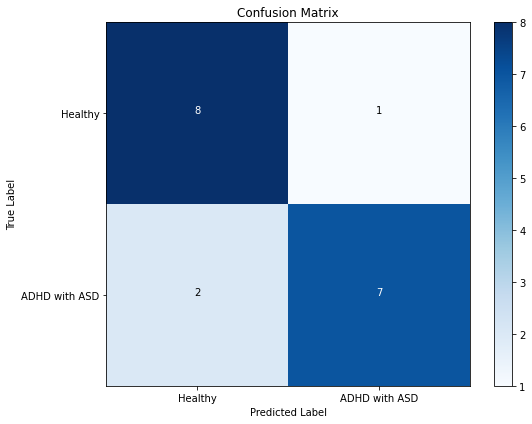

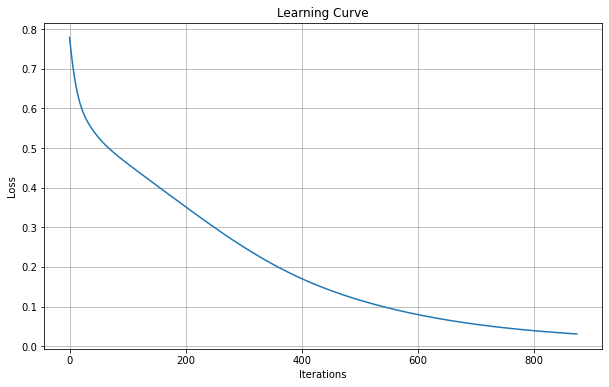

In [12]:
# Evaluate model on test set
y_pred = best_mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Healthy', 'ADHD with ASD'])
plt.yticks(tick_marks, ['Healthy', 'ADHD with ASD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(best_mlp.loss_curve_)
plt.title('Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()



Feature Importance:
             Feature  Importance
13         LoopCount    0.094444
11      ReglineSlope    0.085078
12  ReglineIntercept    0.078147
2           Velocity    0.074896
3            P_min_V    0.070688
4            P_min_A    0.068975
8              Error    0.067732
9          AngleMean    0.067355
1             Length    0.064682
14        AngleSpeed    0.064063
10          AngleVar    0.059788
7            GA_SD_V    0.054296
0             Height    0.053907
5          GA_mean_V    0.048192
6            GA_SD_H    0.047757


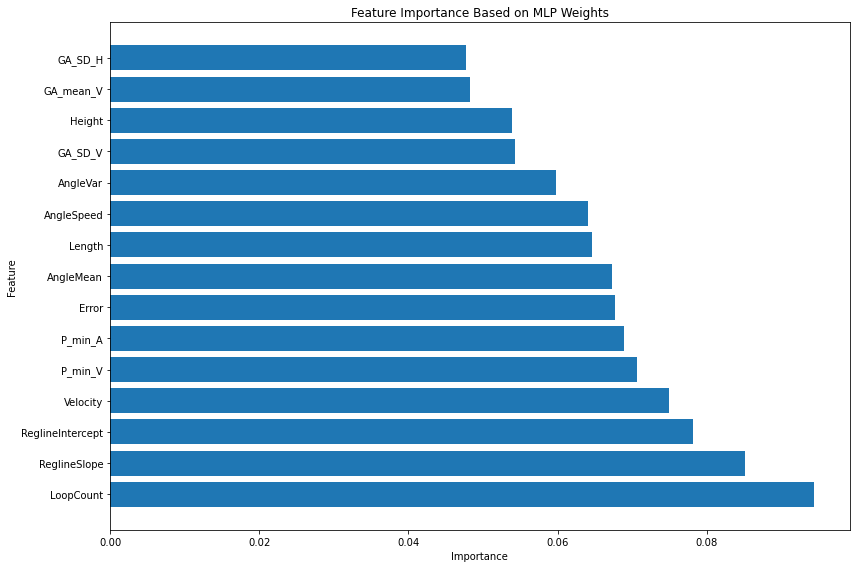

In [13]:
# Visualize feature importance using weights from the first layer
def get_feature_importance(model, feature_names):
    # Get absolute weights from the first layer
    weights = np.abs(model.coefs_[0])
    importance = np.sum(weights, axis=1)
    importance = importance / np.sum(importance)  # Normalize
    
    # Create DataFrame for better visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    return importance_df.sort_values('Importance', ascending=False)

# Get feature importance
feature_importance = get_feature_importance(best_mlp, selected_features)
print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Based on MLP Weights')
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot training history (accuracy and loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

XGBOOST IN GRADIANT BOOST METHOD WITH ZIGZAG_PREDICT

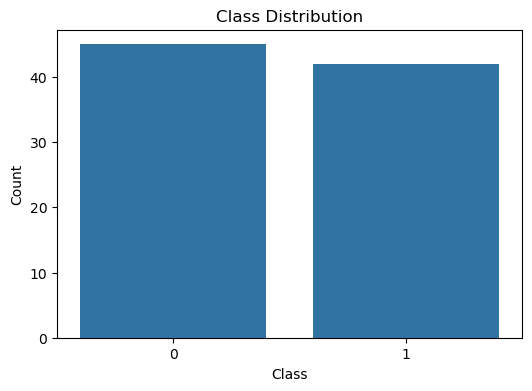

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:07:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.5556

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.67      0.60         9
           1       0.57      0.44      0.50         9

    accuracy                           0.56        18
   macro avg       0.56      0.56      0.55        18
weighted avg       0.56      0.56      0.55        18



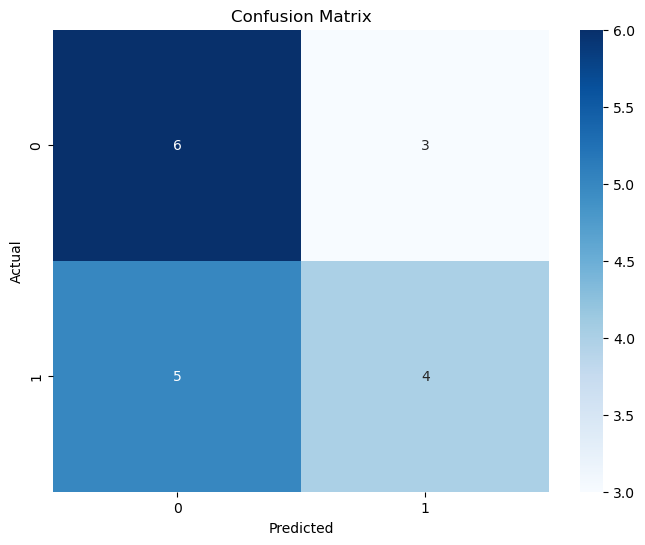

In [225]:
# Install XGBoost if you haven't already
# !pip install xgboost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv('ADHD-ASD-Dataset/Dataset/Zigzag_predict.csv')

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Step 2: Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Feature Scaling (important for XGBoost sometimes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build and train the XGBoost model
model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=len(np.unique(y)),  # Number of classes
    eval_metric='mlogloss',  # Log loss for multi-class
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


XGBOOST IN GRADIANT BOOST WITH ZIGZAG_TRACE

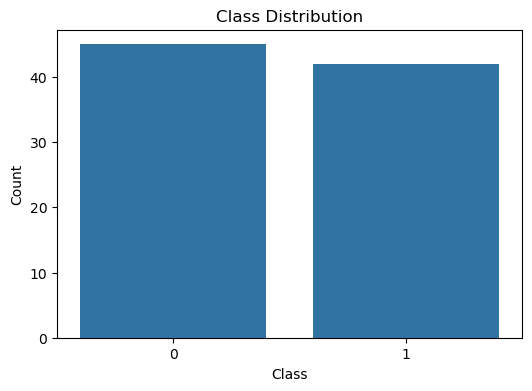

Test Accuracy: 0.5556

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.78      0.64         9
           1       0.60      0.33      0.43         9

    accuracy                           0.56        18
   macro avg       0.57      0.56      0.53        18
weighted avg       0.57      0.56      0.53        18



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:07:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


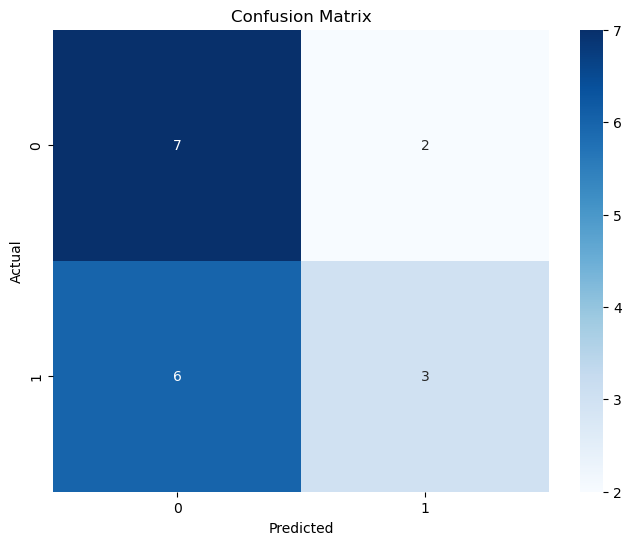

In [227]:
# Install XGBoost if you haven't already
# !pip install xgboost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv('ADHD-ASD-Dataset/Dataset/Zigzag_trace.csv')

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Step 2: Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Feature Scaling (important for XGBoost sometimes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build and train the XGBoost model
model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=len(np.unique(y)),  # Number of classes
    eval_metric='mlogloss',  # Log loss for multi-class
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


XGBOOST IN GRADIANT BOOST METHOD WITH PL_TRACE

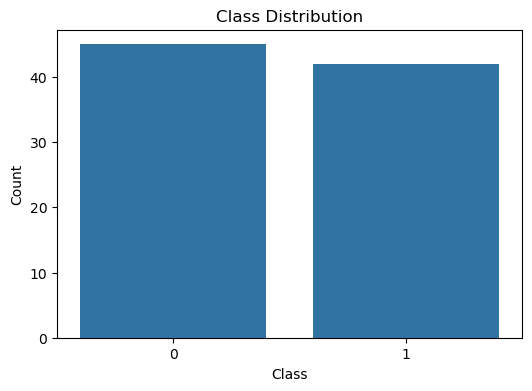

Test Accuracy: 0.7778

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.73      0.89      0.80         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:08:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


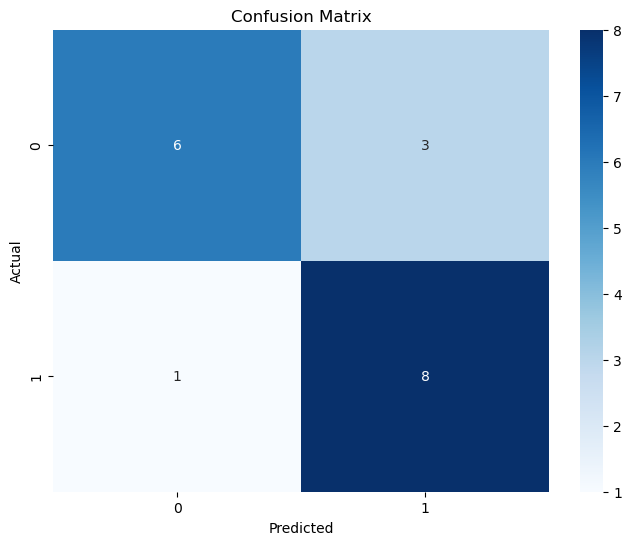

In [229]:
# Install XGBoost if you haven't already
# !pip install xgboost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv('ADHD-ASD-Dataset/Dataset/Pl_trace.csv')

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Step 2: Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Feature Scaling (important for XGBoost sometimes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build and train the XGBoost model
model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=len(np.unique(y)),  # Number of classes
    eval_metric='mlogloss',  # Log loss for multi-class
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


XGBOOST IN GRADIANT BOOST WITH PL_PREDICT

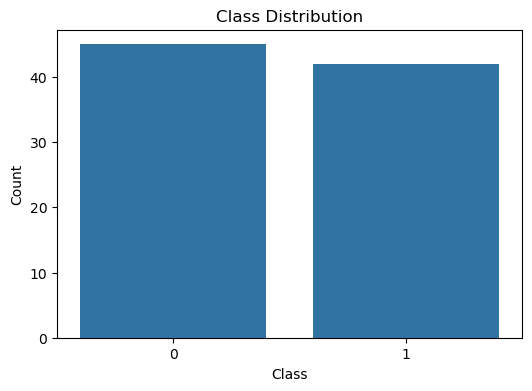

Test Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.89      0.89      0.89         9

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:08:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


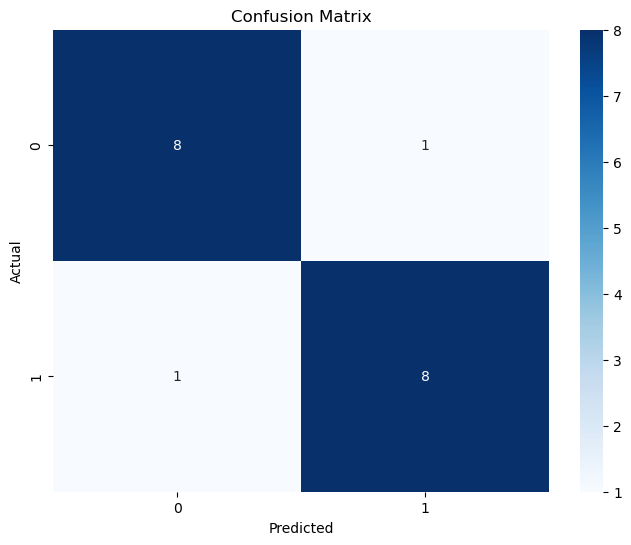

In [231]:
# Install XGBoost if you haven't already
# !pip install xgboost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv('ADHD-ASD-Dataset/Dataset/Pl_predict.csv')

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Step 2: Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Feature Scaling (important for XGBoost sometimes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build and train the XGBoost model
model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=len(np.unique(y)),  # Number of classes
    eval_metric='mlogloss',  # Log loss for multi-class
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


RANDOM FORST CLASSIFIER WITH ZIGZAG_PREDICT

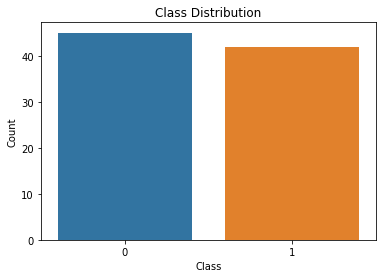

Test Accuracy: 0.7222

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.89      0.76         9
           1       0.83      0.56      0.67         9

    accuracy                           0.72        18
   macro avg       0.75      0.72      0.71        18
weighted avg       0.75      0.72      0.71        18



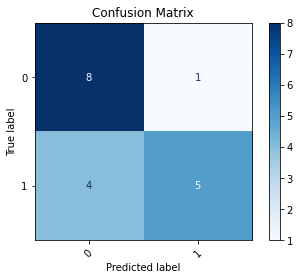

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_predict.csv")  # Replace with your path if needed

# -----------------------------
# 1. Dataset Visualization
# -----------------------------

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# # Correlation heatmap (if numeric)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Feature Correlation Matrix")
# plt.show()

# -----------------------------
# 2. Preprocessing
# -----------------------------
X = df.drop(columns='Class')
y = df['Class']

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 3. Train Random Forest Model
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# -----------------------------
# 4. Evaluate & Visualize Results
# -----------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


RANDOM FOREST CLASSIFIER WITH ZIGZAG_TRACE

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("ADHD-ASD-Dataset/Dataset/Zigzag_trace.csv")  # Replace with your path if needed

# -----------------------------
# 1. Dataset Visualization
# -----------------------------

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# # Correlation heatmap (if numeric)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Feature Correlation Matrix")
# plt.show()

# -----------------------------
# 2. Preprocessing
# -----------------------------
X = df.drop(columns='Class')
y = df['Class']

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 3. Train Random Forest Model
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# -----------------------------
# 4. Evaluate & Visualize Results
# -----------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


RANDOM FOREST CLASSIFIER WITH PL_TRACE

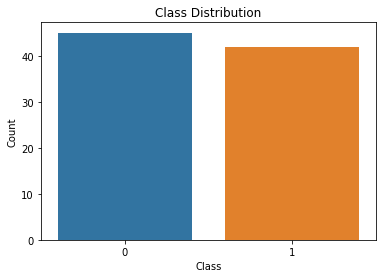

Test Accuracy: 0.7778

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.78      0.78      0.78         9

    accuracy                           0.78        18
   macro avg       0.78      0.78      0.78        18
weighted avg       0.78      0.78      0.78        18



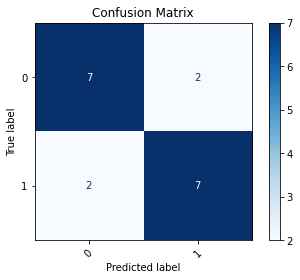

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("ADHD-ASD-Dataset/Dataset/Pl_trace.csv")  # Replace with your path if needed

# -----------------------------
# 1. Dataset Visualization
# -----------------------------

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# # Correlation heatmap (if numeric)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Feature Correlation Matrix")
# plt.show()

# -----------------------------
# 2. Preprocessing
# -----------------------------
X = df.drop(columns='Class')
y = df['Class']

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 3. Train Random Forest Model
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# -----------------------------
# 4. Evaluate & Visualize Results
# -----------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


RANDOM FOREST CLASSIFIER WITH PL_PREDICT

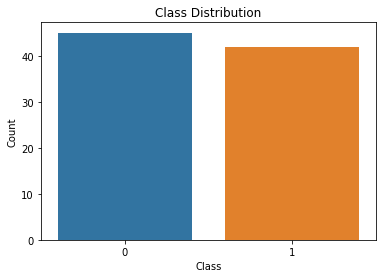

Test Accuracy: 0.8889

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.89      0.89      0.89         9

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18



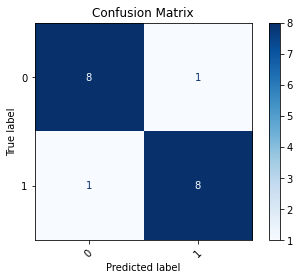

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("ADHD-ASD-Dataset/Dataset/Pl_predict.csv")  # Replace with your path if needed

# -----------------------------
# 1. Dataset Visualization
# -----------------------------

# Display class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# # Correlation heatmap (if numeric)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Feature Correlation Matrix")
# plt.show()

# -----------------------------
# 2. Preprocessing
# -----------------------------
X = df.drop(columns='Class')
y = df['Class']

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 3. Train Random Forest Model
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# -----------------------------
# 4. Evaluate & Visualize Results
# -----------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
